In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp
from scipy.optimize import curve_fit


#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])


CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_color_cycle)

plt.rcParams['font.size'] = 18
plt.rcParams['legend.fontsize'] = 14

In [2]:
### DATA argregation

nametemplate = "IDS/dipoles_1stshell_t0_id"
res = np.zeros((100,3))
res[:,0] = np.arange(1,101)
for i in range(1,101):
    data = np.loadtxt(f"{nametemplate}_E{i}.txt")
    res[i-1,1] = np.mean(data[:,0])
    res[i-1,2] = np.std(data[:,0])/np.sqrt(50) * 3
    
np.savetxt(f"{nametemplate}_All.txt", res)

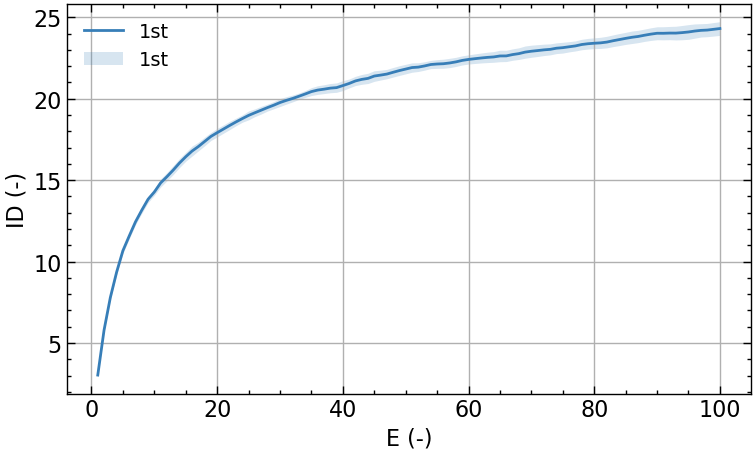

In [3]:
fig, ax = plt.subplots()

ax.set_xlabel("E (-)")
ax.set_ylabel("ID (-)")

ax.plot(res[:,0], res[:,1], label = "1st", ls = "-" , color = CB_color_cycle[0])
ax.fill_between(res[:,0], res[:,1]-res[:,2], res[:,1]+res[:,2], label = "1st", color = CB_color_cycle[0], alpha=0.2, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("autocorr_HDL.pdf")
plt.show()
